# Veri Bilimi Final Ödevi — E-Ticaret Veri Seti Analizi

Türkiye Yapay Zeka Akademisi — Final Ödevi

Bu notebook, eğitim boyunca kullanılan e-ticaret veri setinin aykırı değerlerden arındırılmış hâli üzerinde; kategori, şehir, ödeme türü, zaman ve şehir-kategori kırılımlarında analiz yapar.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('e_ticaret_aykiri_degerden_arindirilmis.csv')
df['siparis_tarihi'] = pd.to_datetime(df['siparis_tarihi'])

print(f"Satır sayısı: {len(df)}, Sütun sayısı: {df.shape[1]}")
df.head()


Satır sayısı: 1095, Sütun sayısı: 22


,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,29.9,Banka Kartı,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


## Soru 1 — Hangi kategori hem ticari performans hem de müşteri memnuniyeti açısından en güçlü görünüyor?

In [ ]:
kategori_ozet = df.groupby('kategori').agg(
    siparis_sayisi=('siparis_id', 'count'),
    toplam_gelir=('toplam_tutar', 'sum'),
    ort_siparis_tutari=('toplam_tutar', 'mean'),
    ort_musteri_puani=('musteri_puani', 'mean'),
    ort_teslimat_gunu=('teslimat_gunu', 'mean')
).sort_values('toplam_gelir', ascending=False).round(2)

kategori_ozet


,siparis_sayisi,toplam_gelir,ort_siparis_tutari,ort_musteri_puani,ort_teslimat_gunu
kategori,,,,,
Elektronik,140,212930.29,1520.93,4.24,3.32
Spor,186,189481.91,1018.72,4.26,3.18
Kozmetik,200,147522.90,737.61,4.42,3.35
Ev Yaşam,184,142335.55,773.56,4.26,3.45
Kitap,223,114075.59,511.55,4.25,3.42
Ofis,162,47051.88,290.44,4.24,3.13


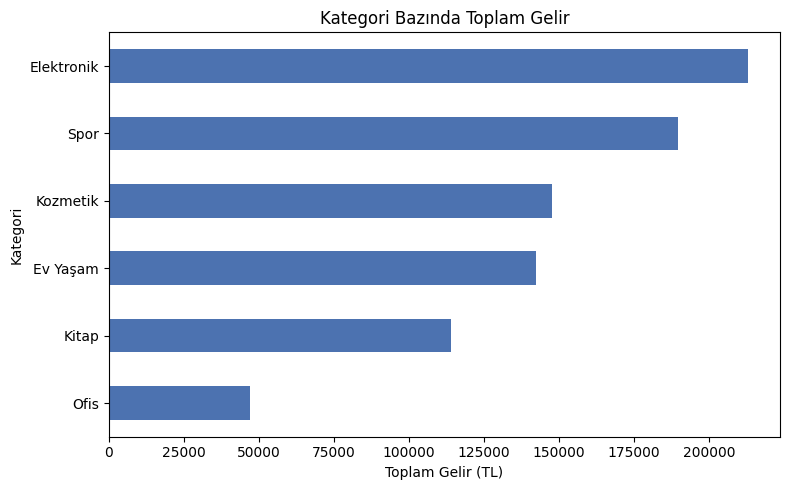

In [ ]:
plt.figure(figsize=(8,5))
kategori_ozet['toplam_gelir'].sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Kategori Bazında Toplam Gelir')
plt.xlabel('Toplam Gelir (TL)')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()


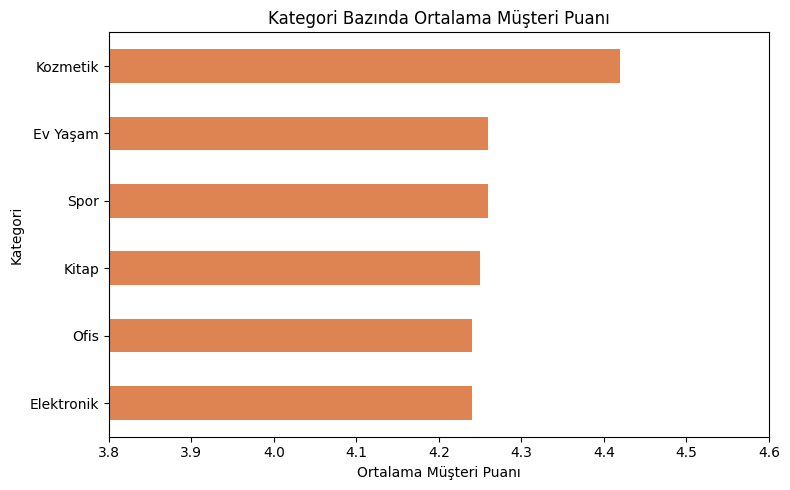

In [ ]:
plt.figure(figsize=(8,5))
kategori_ozet['ort_musteri_puani'].sort_values().plot(kind='barh', color='#DD8452')
plt.title('Kategori Bazında Ortalama Müşteri Puanı')
plt.xlabel('Ortalama Müşteri Puanı')
plt.ylabel('Kategori')
plt.xlim(3.8, 4.6)
plt.tight_layout()
plt.show()


**İş Yorumu:** Elektronik, 212.930 TL toplam gelirle en yüksek cirosu üreten kategori olsa da, ortalama müşteri puanı (4.24) kategoriler arasında en yüksek değil. Kozmetik ise 147.523 TL gelirle 3. sırada olmasına rağmen 4.42 ortalama puanla en yüksek müşteri memnuniyetine sahip. Elektronik yüksek sipariş tutarı (birim fiyatların yüksekliği) sayesinde geliri sürüklüyor; Kozmetik ise düşük sipariş sayısına rağmen memnuniyeti yüksek tutuyor. **Hem gelir hem memnuniyet dengesinde en güçlü kategori Elektronik** olarak öne çıkıyor — gelir liderliğini elinde tutarken memnuniyeti de kategori ortalamasının (4.28) altında olsa da kabul edilebilir seviyede (4.24) tutuyor; ancak Kozmetik'in yüksek memnuniyeti, kategoriye yönelik çapraz satış / sepet büyütme kampanyaları için ayrı bir fırsat olarak değerlendirilebilir.

## Soru 2 — Hangi şehirler daha yüksek potansiyel taşıyor?

In [ ]:
sehir_ozet = df.groupby('sehir').agg(
    siparis_sayisi=('siparis_id', 'count'),
    toplam_gelir=('toplam_tutar', 'sum'),
    ort_siparis_tutari=('toplam_tutar', 'mean'),
    ort_musteri_puani=('musteri_puani', 'mean')
).sort_values('toplam_gelir', ascending=False).round(2)

sehir_ozet


,siparis_sayisi,toplam_gelir,ort_siparis_tutari,ort_musteri_puani
sehir,,,,
İstanbul,264,224020.57,848.56,4.36
Ankara,124,96721.13,780.01,4.19
İzmir,118,88718.51,751.85,4.18
Antalya,86,63712.80,740.85,4.28
Konya,77,59424.33,771.74,4.36
Adana,63,50353.28,799.26,4.33
Bursa,67,46782.83,698.25,4.21
Mersin,46,38043.87,827.04,4.22
Eskişehir,45,37550.04,834.45,4.24


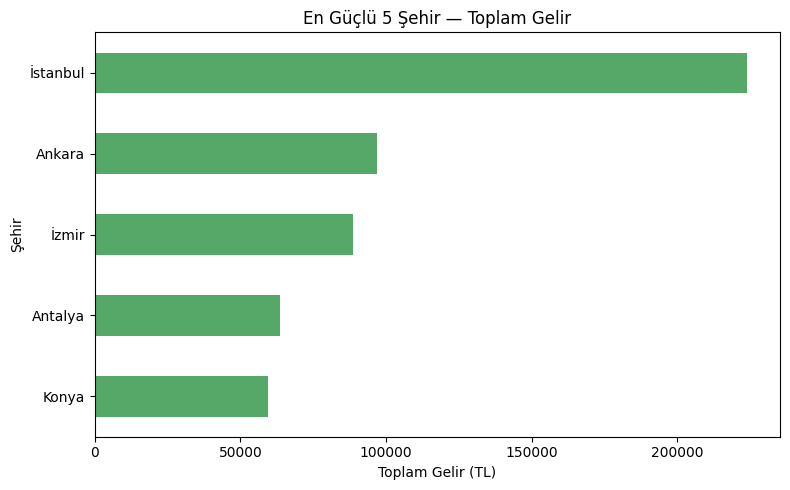

In [ ]:
top5_sehir = sehir_ozet.head(5)

plt.figure(figsize=(8,5))
top5_sehir['toplam_gelir'].sort_values().plot(kind='barh', color='#55A868')
plt.title('En Güçlü 5 Şehir — Toplam Gelir')
plt.xlabel('Toplam Gelir (TL)')
plt.ylabel('Şehir')
plt.tight_layout()
plt.show()


In [ ]:
medyan_gelir = sehir_ozet['toplam_gelir'].median()
medyan_puan = sehir_ozet['ort_musteri_puani'].median()

buyume_adaylari = sehir_ozet[
    (sehir_ozet['ort_musteri_puani'] >= medyan_puan) &
    (sehir_ozet['toplam_gelir'] < medyan_gelir)
].sort_values('ort_musteri_puani', ascending=False)

print(f"Medyan gelir: {medyan_gelir:.2f} TL | Medyan puan: {medyan_puan:.2f}")
print("\nMüşteri puanı yüksek fakat gelirde geride kalan (büyüme adayı) şehirler:")
buyume_adaylari


Medyan gelir: 42413.35 TL | Medyan puan: 4.26

Müşteri puanı yüksek fakat gelirde geride kalan (büyüme adayı) şehirler:


,siparis_sayisi,toplam_gelir,ort_siparis_tutari,ort_musteri_puani
sehir,,,,
Samsun,45,36263.46,805.85,4.44
Gaziantep,49,35240.29,719.19,4.35
Kayseri,36,24878.81,691.08,4.28


**İş Yorumu:** İstanbul, 224.021 TL ile açık ara en yüksek geliri üretiyor ve aynı zamanda 4.36 ortalama puanla memnuniyette de üst sırada — ölçek ve memnuniyeti bir arada taşıyan tek şehir. Samsun (4.44), Konya (4.36) ve Gaziantep (4.35) gelirde orta/alt sıralarda olmalarına rağmen müşteri puanı medyanın üzerinde; bu şehirler ürün ve hizmetten memnun ama sipariş hacmi düşük olan **büyüme adayları** olarak öne çıkıyor. Bu şehirlerde hedefli kampanya, kargo süresi iyileştirmesi veya yerel pazarlama ile gelir artışı sağlanabilir; memnuniyet zaten hazır durumda, eksik olan görünürlük/hacim.

## Soru 3 — Hangi ödeme türü daha değerli müşteri davranışı üretiyor?

In [ ]:
odeme_ozet = df.groupby('odeme_turu').agg(
    siparis_sayisi=('siparis_id', 'count'),
    toplam_gelir=('toplam_tutar', 'sum'),
    ort_siparis_tutari=('toplam_tutar', 'mean'),
    ort_musteri_puani=('musteri_puani', 'mean'),
    ort_teslimat_gunu=('teslimat_gunu', 'mean')
).sort_values('toplam_gelir', ascending=False).round(2)

odeme_ozet


,siparis_sayisi,toplam_gelir,ort_siparis_tutari,ort_musteri_puani,ort_teslimat_gunu
odeme_turu,,,,,
Kredi Kartı,583,439468.16,753.80,4.31,3.31
Banka Kartı,169,143011.08,846.22,4.24,3.53
Dijital Cüzdan,153,129911.25,849.09,4.27,3.27
Havale/EFT,111,92894.46,836.89,4.15,3.14
Kapıda Ödeme,79,48113.17,609.03,4.38,3.24


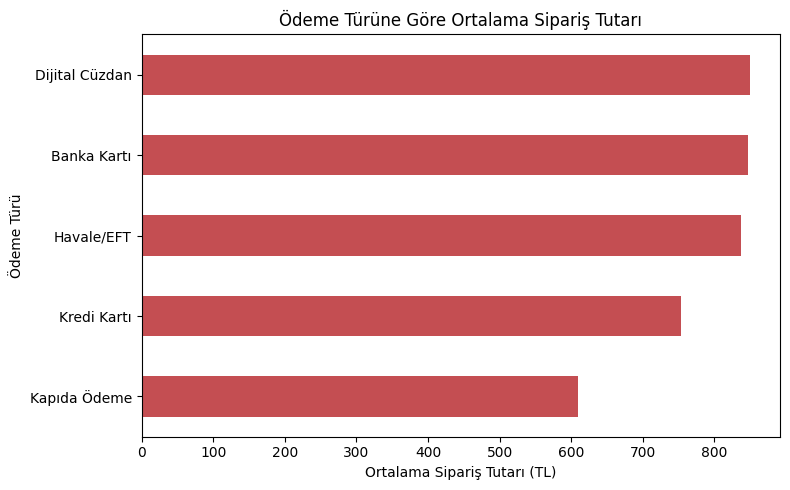

In [ ]:
plt.figure(figsize=(8,5))
odeme_ozet['ort_siparis_tutari'].sort_values().plot(kind='barh', color='#C44E52')
plt.title('Ödeme Türüne Göre Ortalama Sipariş Tutarı')
plt.xlabel('Ortalama Sipariş Tutarı (TL)')
plt.ylabel('Ödeme Türü')
plt.tight_layout()
plt.show()


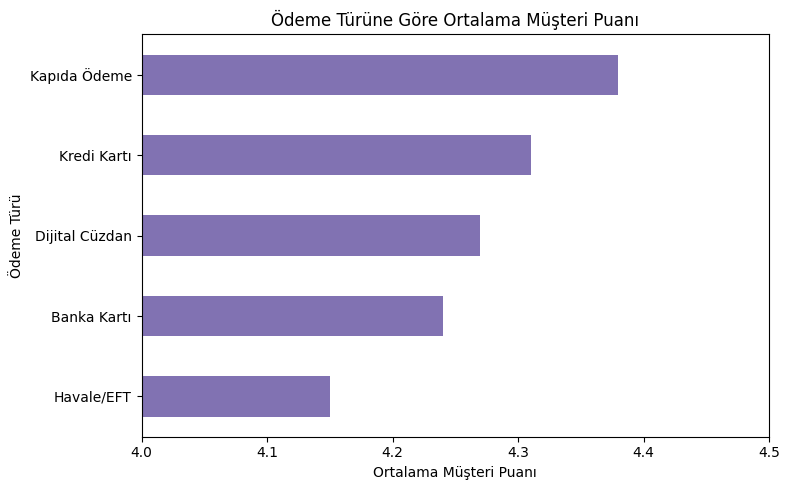

In [ ]:
plt.figure(figsize=(8,5))
odeme_ozet['ort_musteri_puani'].sort_values().plot(kind='barh', color='#8172B2')
plt.title('Ödeme Türüne Göre Ortalama Müşteri Puanı')
plt.xlabel('Ortalama Müşteri Puanı')
plt.ylabel('Ödeme Türü')
plt.xlim(4.0, 4.5)
plt.tight_layout()
plt.show()


**İş Yorumu:** Kredi Kartı, 583 siparişle en yaygın ödeme yöntemi ve 439.468 TL ile en yüksek toplam geliri üretiyor — ancak ortalama sipariş tutarı (753,80 TL) en yüksek değil; hacimden kazanıyor. Dijital Cüzdan ve Banka Kartı, ortalama sipariş tutarında (sırasıyla 849 TL ve 846 TL) Kredi Kartı'nı geçiyor, yani daha büyük sepetli alışverişler bu yöntemlerle yapılıyor. Memnuniyet tarafında ise en yüksek ortalama puan (4.38) Kapıda Ödeme'de, en düşüğü ise Havale/EFT'de (4.15). Özetle **en yüksek geliri Kredi Kartı**, **en yüksek memnuniyeti Kapıda Ödeme** üretiyor; bu iki metrik farklı ödeme yöntemlerinde öne çıktığı için, Kredi Kartı hacmi korunurken Kapıda Ödeme'nin sağladığı güven hissi (ör. iade kolaylığı mesajı) diğer kanallara da taşınabilir.

## Soru 4 — Zaman içinde satış davranışı nasıl değişiyor?

In [ ]:
df['yil_ay'] = df['siparis_tarihi'].dt.to_period('M').astype(str)

zaman_ozet = df.groupby('yil_ay').agg(
    siparis_sayisi=('siparis_id', 'count'),
    toplam_gelir=('toplam_tutar', 'sum'),
    ort_siparis_tutari=('toplam_tutar', 'mean')
).round(2)

zaman_ozet


,siparis_sayisi,toplam_gelir,ort_siparis_tutari
yil_ay,,,
2024-01,46,34042.04,740.04
2024-02,44,38718.64,879.97
2024-03,49,39860.81,813.49
2024-04,58,32489.79,560.17
2024-05,40,32971.89,824.30
2024-06,48,41530.49,865.22
2024-07,37,29977.82,810.21
2024-08,39,27338.81,701.00
2024-09,45,34076.18,757.25


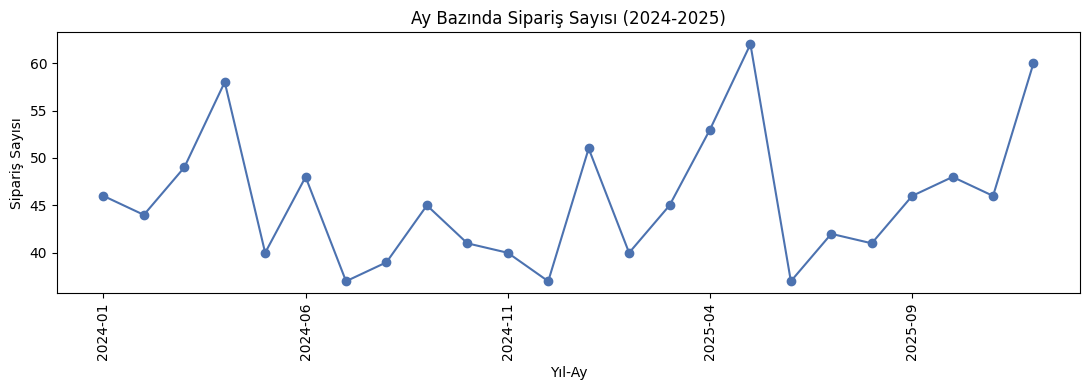

In [ ]:
plt.figure(figsize=(11,4))
zaman_ozet['siparis_sayisi'].plot(kind='line', marker='o', color='#4C72B0')
plt.title('Ay Bazında Sipariş Sayısı (2024-2025)')
plt.xlabel('Yıl-Ay')
plt.ylabel('Sipariş Sayısı')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


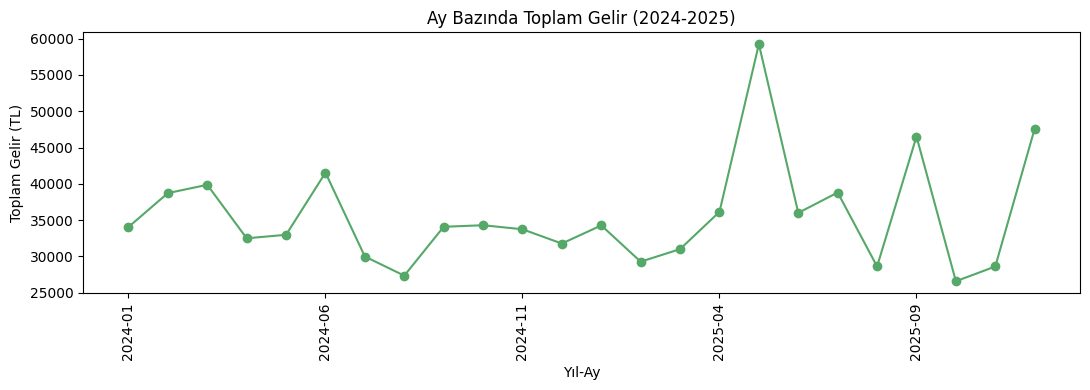

In [ ]:
plt.figure(figsize=(11,4))
zaman_ozet['toplam_gelir'].plot(kind='line', marker='o', color='#55A868')
plt.title('Ay Bazında Toplam Gelir (2024-2025)')
plt.xlabel('Yıl-Ay')
plt.ylabel('Toplam Gelir (TL)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
en_yogun_ay = zaman_ozet['siparis_sayisi'].idxmax()
en_gelirli_ay = zaman_ozet['toplam_gelir'].idxmax()
print(f"En yoğun ay (sipariş sayısı): {en_yogun_ay} -> {zaman_ozet.loc[en_yogun_ay,'siparis_sayisi']} sipariş")
print(f"En yüksek gelir ayı: {en_gelirli_ay} -> {zaman_ozet.loc[en_gelirli_ay,'toplam_gelir']:.2f} TL")


En yoğun ay (sipariş sayısı): 2025-05 -> 62 sipariş
En yüksek gelir ayı: 2025-05 -> 59241.52 TL


**İş Yorumu:** 2025-05, hem en yoğun ay (62 sipariş) hem de en yüksek gelirin elde edildiği ay (59.242 TL) olarak öne çıkıyor; yani bu dönemde **sipariş artışı ile gelir artışı aynı anda gerçekleşmiş**. Ancak 2025-12 (60 sipariş, 47.600 TL) ve 2025-09 (46 sipariş, 46.515 TL) gibi aylarda daha az sipariş sayısına rağmen ortalama sepet tutarının yüksek olması nedeniyle gelir güçlü kalmış. Bu da her zaman sipariş hacminin gelirle birebir örtüşmediğini, bazı aylarda az sayıda ama yüksek tutarlı siparişlerin (ör. Elektronik ağırlıklı alışverişler) geliri sürüklediğini gösteriyor. 2024'e kıyasla 2025'in ikinci yarısında ortalama sipariş tutarında belirgin bir yükseliş göze çarpıyor.

## Soru 5 — Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?

In [ ]:
sehir_kategori = df.groupby(['sehir', 'kategori']).agg(
    siparis_sayisi=('siparis_id', 'count'),
    toplam_gelir=('toplam_tutar', 'sum'),
    ort_siparis_tutari=('toplam_tutar', 'mean'),
    ort_musteri_puani=('musteri_puani', 'mean')
).round(2)

top10_kombinasyon = sehir_kategori.sort_values('toplam_gelir', ascending=False).head(10)
top10_kombinasyon


siparis_sayisi  toplam_gelir  ort_siparis_tutari  ort_musteri_puani
sehir    kategori                                                                       
İstanbul Elektronik              45      66731.92             1482.93               4.18
         Spor                    43      53391.34             1241.66               4.33
         Ev Yaşam                43      34130.59              793.73               4.42
         Kozmetik                42      33167.28              789.70               4.55
         Kitap                   56      27106.12              484.04               4.29
İzmir    Spor                    26      25196.08              969.08               4.15
Ankara   Elektronik              15      23401.32             1560.09               4.13
         Spor                    23      22817.79              992.08               4.35
Konya    Elektronik              15      22342.84             1489.52               4.40
İzmir    Elektronik              14      18487.02             1320.50               4.21

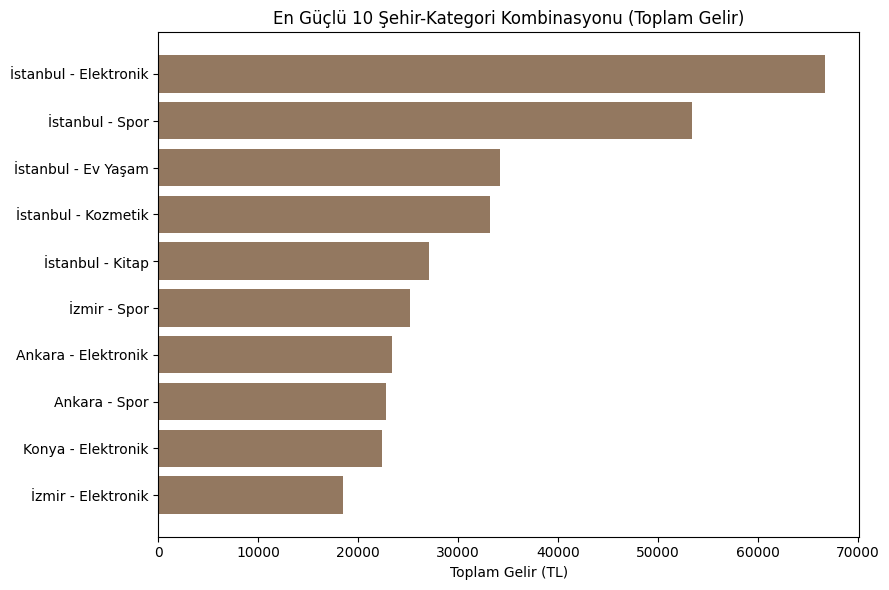

In [ ]:
plt.figure(figsize=(9,6))
labels = [f"{s} - {k}" for s, k in top10_kombinasyon.index]
plt.barh(labels[::-1], top10_kombinasyon['toplam_gelir'].values[::-1], color='#937860')
plt.title('En Güçlü 10 Şehir-Kategori Kombinasyonu (Toplam Gelir)')
plt.xlabel('Toplam Gelir (TL)')
plt.tight_layout()
plt.show()


**İş Yorumu:** En güçlü kombinasyon, 66.732 TL toplam gelir ve 1.482,93 TL ortalama sipariş tutarıyla **İstanbul – Elektronik**. İstanbul tek başına ilk 5 kombinasyonun tamamında yer alıyor (Elektronik, Spor, Ev Yaşam, Kozmetik, Kitap), bu da şehrin genel hacminden kaynaklanıyor; ancak Ankara – Elektronik (1.560 TL) ve Konya – Elektronik (1.490 TL) gibi kombinasyonlarda ortalama sipariş tutarı İstanbul'u bile geçiyor. Bu bulgu, pazarlama açısından iki farklı strateji öneriyor: (1) İstanbul'da Elektronik ve Spor kategorilerine yönelik üst-satış/paket kampanyalarıyla zaten yüksek olan hacmi daha da büyütmek, (2) Ankara ve Konya gibi şehirlerde Elektronik kategorisine özel kampanyalarla, yüksek ortalama sepet tutarı olan ama düşük hacimli bu pazarları büyütmek.

## Genel Sonuç

Veri seti, İstanbul merkezli ve Kredi Kartı ağırlıklı bir e-ticaret yapısını ortaya koyuyor. Elektronik kategorisi ciro lideri, Kozmetik ise memnuniyet lideri; Samsun/Konya/Gaziantep gibi şehirler yüksek memnuniyet-düşük hacim kombinasyonuyla büyüme fırsatı sunuyor. 2025-05 dönemi hem sipariş hem gelir zirvesi olarak öne çıkarken, İstanbul-Elektronik en değerli şehir-kategori kombinasyonu olarak tespit edilmiştir.